### EDA cont.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

In [2]:
da = pd.read_csv('cleaned_school_data_updated.csv')

In [3]:
da.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14467 entries, 0 to 14466
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Report Category       14467 non-null  object 
 1   DBN                   14467 non-null  object 
 2   school_name           14467 non-null  object 
 3   Grade                 14467 non-null  object 
 4   Year                  14467 non-null  int64  
 5   Student Category      14467 non-null  object 
 6   number_tested         14467 non-null  int64  
 7   mean_scale_score      14389 non-null  float64
 8   level_1_count         14389 non-null  float64
 9   level_1_percentage    14389 non-null  float64
 10  level_2_count         14389 non-null  float64
 11  level_2_percentage    14389 non-null  float64
 12  level_3_count         14389 non-null  float64
 13  level_3_percentage    14389 non-null  float64
 14  level_4_count         14389 non-null  float64
 15  level_4_percentage 

In [4]:
da_clean = da.dropna(subset=['% Poverty', 'mean_scale_score'])

In [5]:
da_clean['School Level'] = da_clean['Grade'].apply(lambda x: 'Elementary' if x in ['3','4','5'] else 'Middle')

C:\Users\madis\AppData\Local\Temp\ipykernel_5592\241498269.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  da_clean['School Level'] = da_clean['Grade'].apply(lambda x: 'Elementary' if x in ['3','4','5'] else 'Middle')


In [6]:
da_clean = da_clean[da_clean['Grade'] != 'All Grades']


In [7]:
da_clean['poverty_clean'] = da_clean['% Poverty'] * 100

In [8]:
da_clean_2019 = da_clean[da_clean['Year'] == 2019]

In [9]:
da_clean['DBN'].nunique()

1121

In [10]:
da_clean.describe()

,Year,number_tested,mean_scale_score,level_1_count,level_1_percentage,level_2_count,level_2_percentage,level_3_count,level_3_percentage,level_4_count,level_4_percentage,level_3_4_count,level_3_4_percentage,% Poverty,Poverty_Category,poverty_clean
count,11093.000000,11093.000000,11093.000000,11093.000000,11093.000000,11093.000000,11093.000000,11093.000000,11093.000000,11093.000000,11093.000000,11093.000000,11093.000000,11093.000000,11093.000000,11093.000000
mean,2019.678266,95.529703,600.110340,21.126566,23.975399,27.459028,30.378112,26.883530,28.007771,20.060579,17.640593,46.944109,45.647796,0.750672,0.659876,75.067232
std,1.701719,83.120390,10.245318,21.818069,16.515831,23.565832,11.304778,25.652923,13.137564,33.631573,16.979351,53.757150,21.874645,0.216148,0.473772,21.614783
min,2018.000000,6.000000,558.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.056000,0.000000,5.600000
25%,2018.000000,49.000000,593.000000,7.000000,10.600000,13.000000,23.000000,11.000000,18.800000,3.000000,5.300000,16.000000,28.300000,0.671000,0.000000,67.100000
50%,2019.000000,75.000000,599.000000,15.000000,21.500000,22.000000,30.800000,20.000000,26.300000,9.000000,12.300000,31.000000,42.900000,0.824000,1.000000,82.400000
75%,2022.000000,112.000000,607.000000,28.000000,35.300000,34.000000,38.000000,34.000000,34.800000,23.000000,25.000000,58.000000,61.600000,0.920000,1.000000,92.000000
max,2022.000000,745.000000,644.000000,333.000000,100.000000,279.000000,75.000000,219.000000,89.900000,421.000000,100.000000,494.000000,100.000000,0.950000,1.000000,95.000000


In [11]:
print(da_clean.groupby(['Grade', 'Year']).size())

Grade  Year
3      2018    764
       2019    774
       2022    776
4      2018    750
       2019    764
       2022    770
5      2018    743
       2019    756
       2022    775
6      2018    474
       2019    476
       2022    474
7      2018    466
       2019    467
       2022    469
8      2018    466
       2019    464
       2022    465
dtype: int64


In [38]:
print(da_clean.groupby('Year')['poverty_clean'].max())
print(da_clean.groupby('Year')['mean_scale_score'].mean())
print(da_clean.groupby('Year')['number_tested'].mean())

Year
2018    95.0
2019    95.0
2022    95.0
Name: poverty_clean, dtype: float64
Year
2018    600.548185
2019    599.726560
2022    600.061142
Name: mean_scale_score, dtype: float64
Year
2018    102.776413
2019    101.322345
2022     82.662108
Name: number_tested, dtype: float64


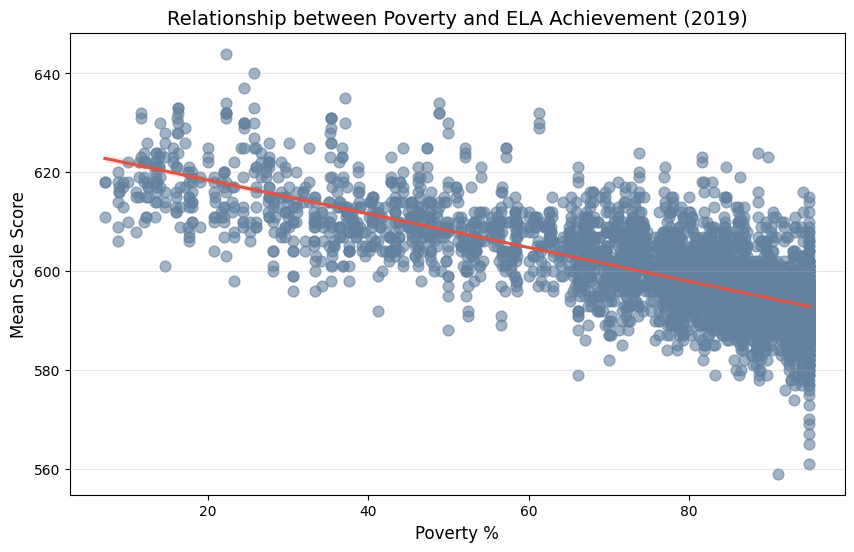

In [13]:



plt.figure(figsize=(10, 6))

sns.regplot(data=da_clean_2019, x='poverty_clean', y='mean_scale_score',
            scatter_kws={'color': "#63819f", 'alpha': 0.6, 's': 60},
            line_kws={'color': "#db5648"})


plt.title('Relationship between Poverty and ELA Achievement (2019)', fontsize=14)
plt.xlabel('Poverty %', fontsize=12)
plt.ylabel('Mean Scale Score', fontsize=12)
plt.grid(axis='y', alpha=0.3)

plt.show()

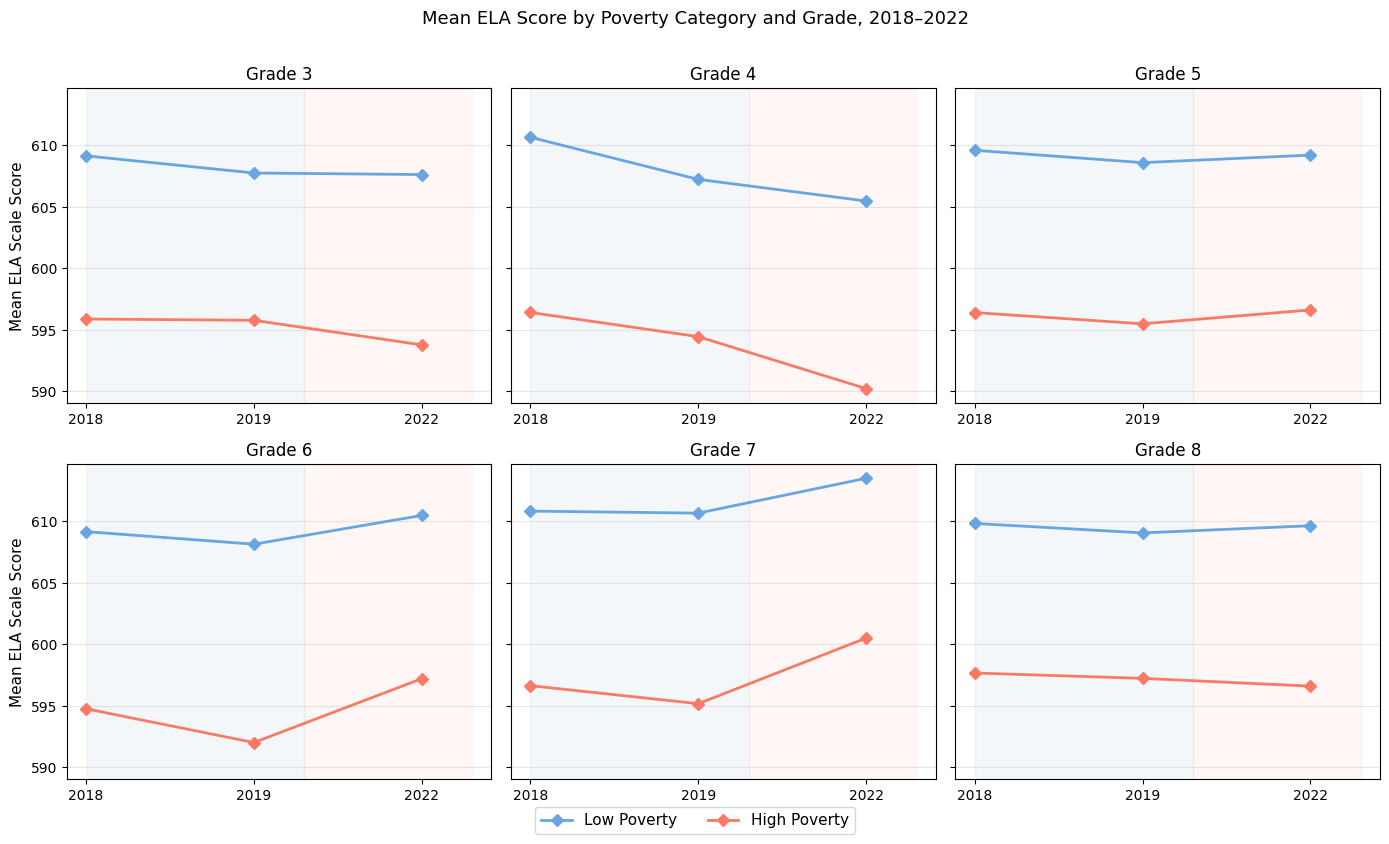

In [15]:
# colors and labels for poverty categories
grades = ['3', '4', '5', '6', '7', '8']
colors = {0: "#68a5e1", 1: "#fb7a66"}
labels = {0: 'Low Poverty', 1: 'High Poverty'}
x = [0, 1, 2]
year_labels = ['2018', '2019', '2022']

# create subplots for each grade
# 2x3
fig, axes = plt.subplots(2, 3, figsize=(14, 8), sharey=True)
axes = axes.flatten()

# looping through grades and plotting for poverty category (high/low) where cutoff is 60%
for i, grade in enumerate(grades):
    ax = axes[i]
    grade_data = da_clean[da_clean['Grade'] == grade]

    # plot mean scores for low and high poverty categories
    for cat in [0, 1]:
        means = (
            grade_data[grade_data['Poverty_Category'] == cat]
            .groupby('Year')['mean_scale_score']
            .mean()
            .sort_index()
        )
        # line plot with markers for each year
        ax.plot(x, means.values, marker='D', linewidth=2, markersize=6.5,
                color=colors[cat], label=labels[cat])

    # pre covid period set from 2018 to roughly 2020
    ax.axvspan(0, 1.3, alpha=0.06, color='steelblue')
    # post covid period from 2020 to 2022
    ax.axvspan(1.3, 2.3, alpha=0.06, color='salmon')
    # year labels
    ax.set_xticks(x)
    ax.set_xticklabels(year_labels, fontsize=10)
    # title and grid for each subplot
    ax.set_title(f'Grade {grade}', fontsize=12)
    ax.grid(axis='y', alpha=0.3)

# y axis label on the left 
for row_ax in [axes[0], axes[3]]:
    row_ax.set_ylabel('Mean ELA Scale Score', fontsize=11)

# legend & title
handles, lab = axes[0].get_legend_handles_labels()
fig.legend(handles, lab, loc='lower center', ncol=2, fontsize=11, bbox_to_anchor=(0.5, -0.03))
fig.suptitle('Mean ELA Score by Poverty Category and Grade, 2018–2022', fontsize=13, y=1.01)

plt.tight_layout()
plt.show()

In [18]:
# district #

da_clean['school_district'] = da_clean['DBN'].str.extract(r'^(\d{2})')

In [19]:
da_clean['poverty_category_75'] = (da_clean['% Poverty'] >= 0.75).astype(int)  

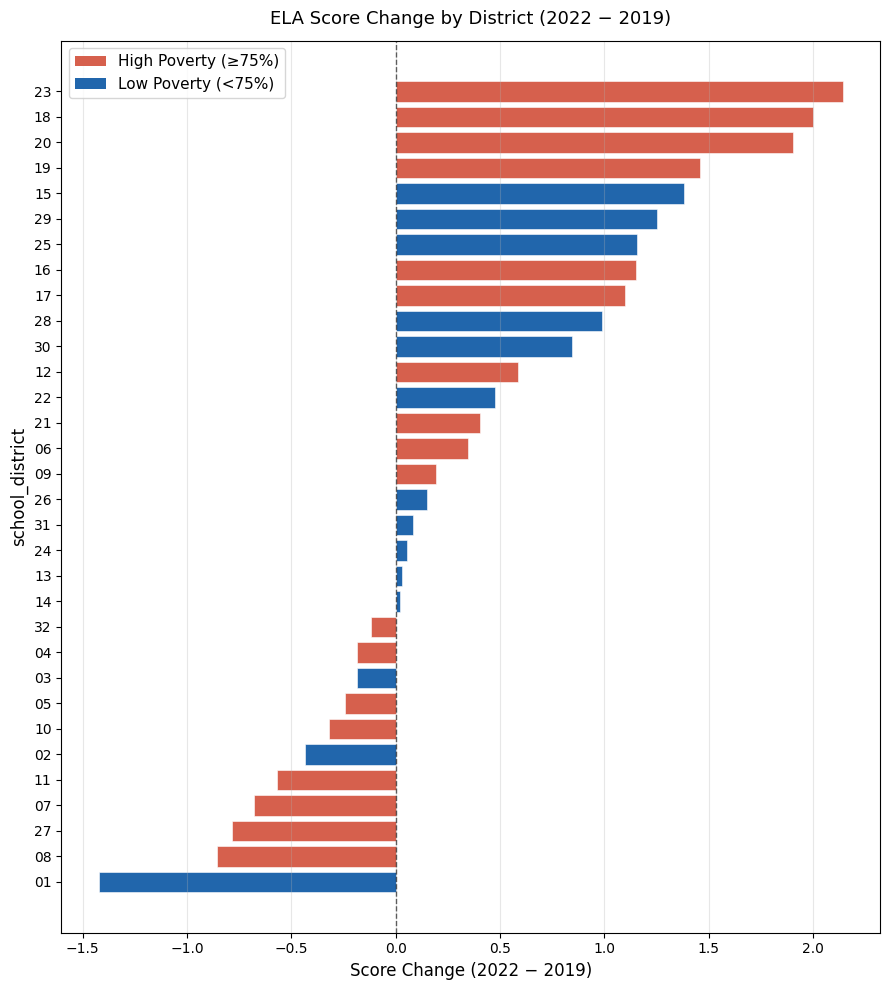

In [22]:
# district-level analysis - why school level is necessary 

# average score change by district, in both 2019 and 2022
dist_2019 = (
    da_clean[da_clean['Year'] == 2019]
    .groupby('school_district')
    .agg(poverty=('% Poverty', 'mean'), score_2019=('mean_scale_score', 'mean'))
    .reset_index()
)
dist_2022 = (
    da_clean[da_clean['Year'] == 2022]
    .groupby('school_district')['mean_scale_score']
    .mean()
    .reset_index()
    .rename(columns={'mean_scale_score': 'score_2022'})
)

# merge to have both years and calculate the change in score by district (2022 - 2019)
district_stats = dist_2019.merge(dist_2022, on='school_district')
district_stats['change_in_score'] = district_stats['score_2022'] - district_stats['score_2019']
district_stats = district_stats.sort_values('change_in_score', ascending=True)

# color bars by poverty category with cutoff at 75%
# was going to be 60% but that ended up being too low because most districts were above threshold
# looked into distribution of poverty percentages and it's all over the place, no concrete district level poverty rates
colors = ['#d6604d' if p >= 0.75 else '#2166ac' for p in district_stats['poverty']]


fig, ax = plt.subplots(figsize=(9, 10))

# horizontal bar plot of change in score by district, colored by poverty category
ax.barh(
    district_stats['school_district'].astype(str),
    district_stats['change_in_score'],
    color=colors,
    edgecolor='white',
    linewidth=0.4
)

# vertical line at 0 to show no change in score
ax.axvline(0, color='black', linewidth=1, linestyle='--', alpha=0.6)

# labeling and titles
ax.set_xlabel('Score Change (2022 − 2019)', fontsize=12)
ax.set_ylabel('school_district', fontsize=12)
ax.set_title('ELA Score Change by District (2022 − 2019)', fontsize=13, pad=12)
ax.grid(axis='x', alpha=0.3)

# legend for poverty categories
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#d6604d', label='High Poverty (≥75%)'),
    Patch(facecolor='#2166ac', label='Low Poverty (<75%)')
]
ax.legend(handles=legend_elements, fontsize=11)

plt.tight_layout()
plt.show()
